## Time Lag Correlation

In Chapter 9 of Taylor, you studied the correlation coefficient between two sets of data.  If the two sets of data are time-dependent, the correlation between the signals may be delayed in time.  Imagine that you drive a process with an oscillating signal and you measure the response, which also oscillates but with a time-delay imposed by the physical response of your system.

One way to analyze the time delay and get at that physical response is to look at the correlation coefficient for various _time lags_.  The expression in Chapter 9 for the correlation coefficient is:

$$ r = \frac{\sum_{i=0}^N (x_i - \overline{x})( y_i - \overline{y})}{\sqrt{(\sum x_i - \overline{x})^2(\sum y_i - \overline{y})^2}}.$$

This compares $x(t)$ with $y(t)$ directly, where $t$ is sampled discretely with a spacing $dt$: $t_i = i dt$.  The index $i$ represents a particular point in the time series -- a particular time -- so each $x$ datapoint is compared with the $y$ datapoint at the same time.  

If we look at $x(t)$ but compare it with $y(t+\tau)$, then we need to use a second index.  If $i$ represents the datapoints at the original time points, then $j = i + n$ represents the time shifted by $n$ points ($\tau = n dt$).  The correlation between $x$ and a delayed copy of $y$ is then:

$$r(n) = \frac{\sum_{i=0}^N (x_i - \overline{x})( y_j - \overline{y})}{\sqrt{\sum (x_i - \overline{x})^2\sum (y_j - \overline{y})^2}}.$$

If we calculate this quantity for all possible values of $n$, we have a correlation _function_.   The delay $n$ at which the correlation is maximized gives us a most likely value for the physical delay time.  

If you prefer the continuous formulation, it looks like this:

$$r(\tau) = \frac{\int\left[x(t) - \overline{x}\right]\left[ y(t+\tau) - \overline{y}\right]dt}{\sqrt{\int\left[ x(t) - \overline{x}\right]^2dt \int\left[y(t+\tau) - \overline{y}\right]^2dt}}.$$

Here's an example:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#define a function that allows me to generate a sine wave with a 
# given frequency and time lag relative to zero
def mysine(t, f = 10., lag=0):
    return np.sin(2*np.pi*f*(t - lag))

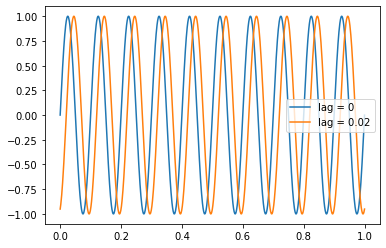

In [3]:
#let's look at some waves:
t = np.linspace(0,1,1000)
#the default frequency is 10 Hz, so a time lag of 0.02s will shift it by 1/5 cycle
s1 = mysine(t)
s2 = mysine(t,lag=0.02)

plt.plot(t, s1, label='lag = 0')
plt.plot(t, s2, label='lag = 0.02')
plt.legend()

The ``np.correlate`` function can be used to calculate the standard correlation coefficient as well as the time-lag correlation function.  It just calculates the numerator of the expressions above, so we need to divide by the product of the standard deviations to get the normalized versions we want:

In [4]:
#for the raw correlation, we use the default settings
corr = np.correlate(s1,s2)
print(corr)

#normalize it
corr_norm = corr/((t.size-1)*s1.std()*s2.std())
print(corr_norm)

[154.35398869]
[0.30904691]


Text(0, 0.5, 'Correlation value (norm)')

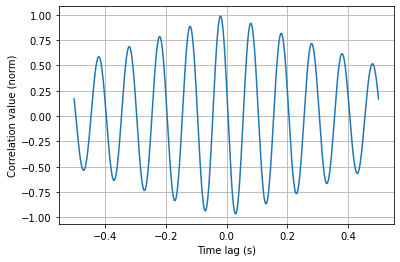

In [8]:
# if we specify that the correlation mode is 'same', then the lag will vary 
# from -half the signal length to + half the signal length to produce
# a correlation function with the same length as the original signals
corr_same = np.correlate(s1,s2,mode='same')

# normalize it
corr_same_norm = corr_same/((t.size-1)*s1.std()*s2.std())

# numpy's correlate function uses the time spacing of the points as lags,
# so the array of lag times is the same number of points as the signals (mode='same')
# and the lag is zero in the center:
dt = t[1]-t[0]
lag = dt*(np.arange(corr_same.size) - corr_same.size/2) 

plt.plot(lag, corr_same_norm)
plt.grid()
plt.xlabel('Time lag (s)')
plt.ylabel('Correlation value (norm)')

In [12]:
#note both that the correlation at zero lag is relatively low (the 0.3 calculated above)
# and that the peak correlation and anticorrelation don't happen at zero lag!

max_lag = lag[corr_same_norm.argmax()]
print(max_lag)

0.02002002002002002


0.02002002002002002


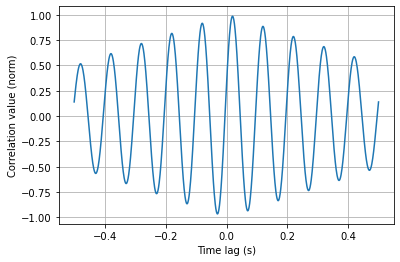

In [13]:
# if you switch the order of the signals, notice what happens:
corr_same = np.correlate(s2,s1,mode='same')

# normalize it
corr_same_norm = corr_same/((t.size-1)*s1.std()*s2.std())

# show the lag plot
plt.plot(lag, corr_same_norm)
plt.grid()
plt.xlabel('Time lag (s)')
plt.ylabel('Correlation value (norm)')

# find the lag with the max correlation value
max_lag = lag[corr_same_norm.argmax()]
print(max_lag)

---
Now that you have some code to work with, you can analyze some data from Dr. Light's plasma jet.  

Plasmas can act as electrical loads that are primarily inductive or primarily capacitive, depending on the arrangement.  Your task is to analyze the time series for the voltage between and current through the plasma electrodes to determine whether this plasma is a capacitive or inductive load and how much relative resistive loss there is.


Remember that for capacitors $I_C = C \frac{dV_C}{dt}$ and for inductors $V_L = -L\frac{dI}{dt}$.  For each case, the voltage and current are out of phase by $90^\circ$.  The capacitor's voltage _lags_ the current because it has to charge up before there is voltage across the plates.  The inductor's voltage _leads_ the current because the induced voltage has to subside before the current can reach its peak.  

There is also usually a little resistance, and resistive loads have current and voltage in phase by Ohm's Law.  We can determine how important the resistance is to the reactance (inductive and capacitive contributions) using _phasors_.  A phasor represents the amplitude and phase of a sinusoidal signal.  For example, in a series RLC circuit, the phasor representation of the current (same throughout circuit) and the voltage across each component is:

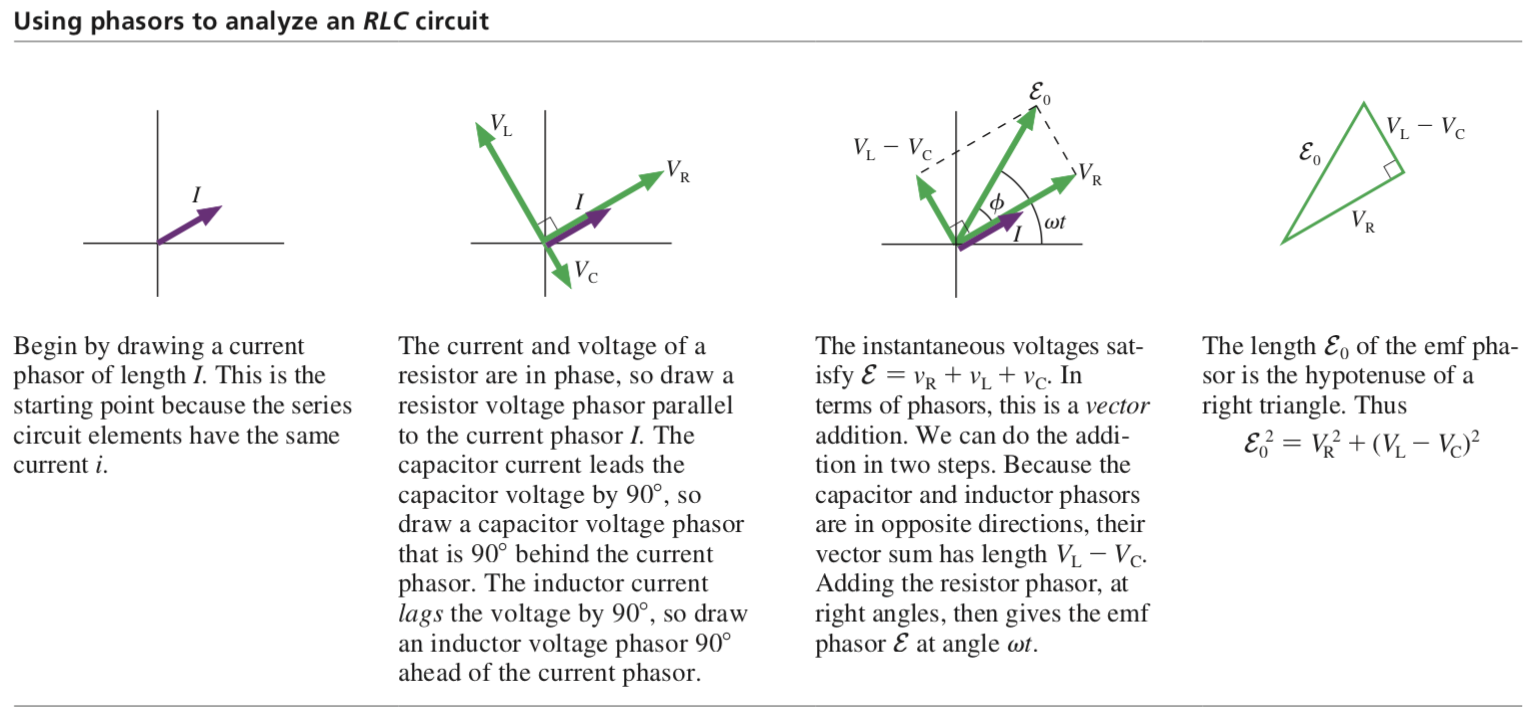

If we know the phase angle between the input voltage ($\mathcal{E}_0$) and the current, we can use these geometric relationships to deduce how important the resistive contribution is.  By looking at the lag between $I$ and $V$ with biggest correlation, we can determine the phase shift between them in the data.  Using that, we can determine whether the dominant behavior is capacitive, inductive, or resistive and the ratio between the reactive and resistive parts of the impedance.  This is your task.

First, let's read in the data:

In [6]:
import numpy as np
import h5py 

#routine to parse oscilloscope data saved to HDF5 file
def get_keysight_data(filename):
    #open file as a data object (`with` statement takes care of 
    # closing the file when the code inside is done running or if
    # the program crashes
    with h5py.File(filename, mode='r') as file_obj:
        #now read out the time base information
        ch1_obj = file_obj['Waveforms']['Channel 1']
        #get total number of points in waveforms
        n = np.arange(ch1_obj.attrs['NumPoints'])
        #get initial time
        t0 = ch1_obj.attrs['XOrg']
        #get time increment
        delta_t = ch1_obj.attrs['XInc']
        
        #construct time array
        time_raw = t0 + (n-1)*delta_t

        #read out voltage data
        ch1_raw = ch1_obj['Channel 1 Data'][()]
        #if we don't need to interact with the object, we can 
        # just address the data directly
        ch2_raw = file_obj['Waveforms']['Channel 2']['Channel 2 Data'][()]
        
    return time_raw, ch1_raw, ch2_raw


#using this function and the knowledge from the experiment log 
# that channel 1 is current and channel 2 is voltage:

t, I, V = get_keysight_data('jet_example_data.h5')

## Exercise #1:

Plot the current and the voltage versus time (together on the same plot).  Which one is leading?  What does that tell you about the dominant character of the circuit (i.e. which of the three components is the whole circuit most like)?

## Exercise #2:

Use the time lag correlation to measure the phase difference between the voltage and current.  The drive frequency is 18 kHz.

## (optional) Exercise #3:

Using the geometry above, determine the ratio of the resistive part of the response to the reactive part of the response using the phase angle from Exercise \#2.  Use this and the frequency to calculate the capacitance and resistance of the setup.